<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_M104_JWST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy M104 (Sombrero) - New Data from JWST**

![sciences](https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/M104_ngc4594_sombrero_galaxy_hi-res.jpg/1024px-M104_ngc4594_sombrero_galaxy_hi-res.jpg)

In [ ]:
!pip install astropy astroquery -q
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
%matplotlib inline

***New data from James Webb telescope***

https://science.nasa.gov/missions/webb/hats-off-to-nasas-webb-sombrero-galaxy-dazzles-in-new-image/

https://webbtelescope.org/contents/media/images/2024/137/01JCGK31M1TXEW8T7PEHHVDDC9?news=true

* Object Name Sombrero Galaxy, M104
* Object Description Edge-on lenticular galaxy
* R.A. Position12:39:59.42
* Dec. Position-11:37:23.0
* Constellation Virgo
* Distance About 29 million light-years away
* Dimensions Image is about 7.2 arcminutes across (60,000 light-years)

In [ ]:
# Access infrared data from JWS instruments
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI', 'NIRSpec', 'NIRISS', 'FGS']
)

# Display the results
print(obs_table)

 intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
----------- -------------- --------------- --------------- ... ------ ------ --------- ---------
calibration           JWST         CALJWST             FGS ...  False    nan  71739127 294621945
calibration           JWST         CALJWST             FGS ...  False    nan  78110357 317255586
calibration           JWST         CALJWST             FGS ...  False    nan  71774526 317392654
calibration           JWST         CALJWST             FGS ...  False    nan  71752546 317392663
calibration           JWST         CALJWST             FGS ...  False    nan  71774896 317557360
calibration           JWST         CALJWST             FGS ...  False    nan  71775531 317557535
calibration           JWST         CALJWST         NIRSPEC ...  False    nan  71776118 317572943
calibration           JWST         CALJWST         NIRSPEC ...  False    nan  71776119 317572979
calibration           JWST    

In [ ]:
# Assuming you've selected specific observations (first one for this example)
data = Observations.get_product_list(obs_table[0])

In [ ]:
# Instead of downloading, just count unique products
unique_products = len(set(data['productFilename']))

# Print the count of unique products
print(f"Number of unique products: {unique_products}")

Number of unique products: 6


In [ ]:
# Show the available data products
print(data)

 obsID   obs_collection dataproduct_type ... dataRights calib_level filters
-------- -------------- ---------------- ... ---------- ----------- -------
71739127           JWST            image ...     PUBLIC           3    OPEN
71739127           JWST            image ...     PUBLIC           3    OPEN
71739127           JWST            image ...     PUBLIC           3    OPEN
71739127           JWST            image ...     PUBLIC           3    OPEN
71739127           JWST            image ...     PUBLIC           3    OPEN
71739127           JWST            image ...     PUBLIC           3    OPEN


In [ ]:
# Download all data
Observations.download_products(data)

Local Path,Status,Message,URL
str98,str8,object,object
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_20230816t064844_image3_00001_asn.json,COMPLETE,None,None
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_cat.ecsv,COMPLETE,None,None
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_i2d.fits,COMPLETE,None,None
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_i2d.jpg,COMPLETE,None,None
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_segm.fits,COMPLETE,None,None
./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147_20230816t064844_pool.csv,COMPLETE,None,None


In [ ]:
# Filter table by column value, based on specific criteria, e.g. only observations using NIRCam
nircam_obs = obs_table[obs_table['instrument_name'] == 'MIRI']
print(nircam_obs)

intentType obs_collection provenance_name instrument_name project ... mtFlag srcDen obsid objID
---------- -------------- --------------- --------------- ------- ... ------ ------ ----- -----


In [ ]:
# Specify the path to the FITS file
fits_file = './mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_i2d.fits'
hdul = fits.open(fits_file)
hdul.info()

Filename: ./mastDownload/JWST/jw01147-o014_t024_fgs_clear/jw01147-o014_t024_fgs_clear_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     340   ()      
  1  SCI           1 ImageHDU        75   (2117, 2119)   float32   
  2  ERR           1 ImageHDU        10   (2117, 2119)   float32   
  3  CON           1 ImageHDU        10   (2117, 2119, 1)   int32   
  4  WHT           1 ImageHDU         9   (2117, 2119)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2117, 2119)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2117, 2119)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2117, 2119)   float32   
  8  HDRTAB        1 BinTableHDU    824   1R x 407C   [23A, 5A, 3A, 42A, 7A, 13A, 3A, 6A, 7A, 10A, 4A, L, D, D, D, D, 32A, 50A, 43A, 24A, 3A, 3A, D, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 24A, 8A, 2A, 27A, 20A, 27A, 10A, K, L, L, L, L, 23A, 23A, 5A, D, D, D, D, D, D, 27A, D, D, D, 3A, 7A,

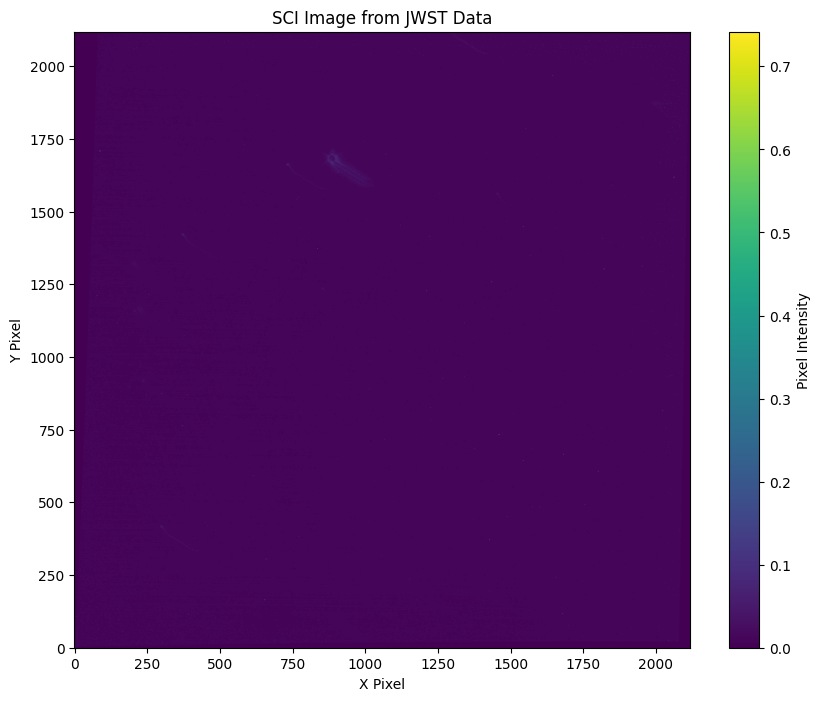

In [ ]:
# Access the data in the 'SCI' HDU
sci_data = hdul[2].data  # HDU 1 contains the image data

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(sci_data, cmap='viridis', origin='lower')
plt.colorbar(label="Pixel Intensity")
plt.title("SCI Image from JWST Data")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.show()

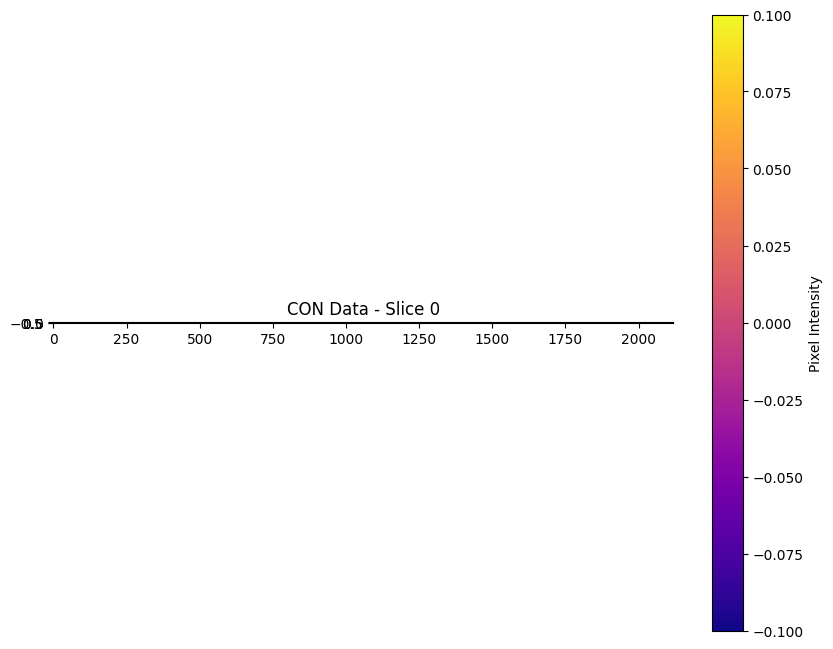

In [ ]:
con_data = hdul[3].data  # HDU 3 contains 3D data
slice_0 = con_data[:, :, 0]  # Extract the first slice along the third axis

plt.figure(figsize=(10, 8))
plt.imshow(slice_0, cmap='plasma', origin='lower')
plt.colorbar(label="Pixel Intensity")
plt.title("CON Data - Slice 0")
plt.show()

*Manually check and load JWST telescope data for NGC 4594 galaxy*

In [ ]:
from astroquery.mast import Observations
obs_table = Observations.query_object("NGC 4594", radius="0.02 deg")
jwst_data = obs_table[obs_table['obs_collection'] == 'JWST']
jwst_data

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,distance
str11,str11,str31,str12,str4,str26,str16,str35,str47,str67,float64,float64,str10,str22,int64,float64,float64,float64,float64,float64,str111,float64,str17,str7,int64,str3331,str181,str182,str16,bool,float64,str9,float64
science,JWST,CALJWST,MIRI/IFU,JWST,CH1,INFRARED,SOMBRERO-MIRI,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-c1012_t023_miri_ch1-shortmediumlong,189.99762625000002,-11.623052777777787,cube,"Seth, Anil C.",3,59764.34827602639,59764.42128994213,2763.936,4900.0,7650.0,Revealing Low Luminosity Active Galactic Nuclei (ReveaLLAGN),60139.5416666,2016,GO,--,POLYGON 189.996708148 -11.623879797 189.996708148 -11.622218686 189.998551509 -11.622218686 189.998551509 -11.623879797,mast:JWST/product/jw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.jpg,mast:JWST/product/jw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits,PUBLIC,False,nan,103276784,0.0
science,JWST,CALJWST,MIRI/IFU,JWST,CH2,INFRARED,SOMBRERO-MIRI,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-c1012_t023_miri_ch2-shortmediumlong,189.99762625000002,-11.623052777777787,cube,"Seth, Anil C.",3,59764.34827602639,59764.42128994213,2763.936,7510.0,11700.0,Revealing Low Luminosity Active Galactic Nuclei (ReveaLLAGN),60139.5416666,2016,GO,--,POLYGON 189.996430382 -11.62393745 189.996430382 -11.621954116 189.998648087 -11.621954116 189.998648087 -11.62393745,mast:JWST/product/jw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg,mast:JWST/product/jw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.fits,PUBLIC,False,nan,103276787,0.0
science,JWST,CALJWST,MIRI/IFU,JWST,CH3,INFRARED,SOMBRERO-MIRI,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-c1012_t023_miri_ch3-shortmediumlong,189.99762625000002,-11.623052777777787,cube,"Seth, Anil C.",3,59764.34827602639,59764.42128994213,2763.936,11550.0,17980.0,Revealing Low Luminosity Active Galactic Nuclei (ReveaLLAGN),60139.5416666,2016,GO,--,POLYGON 189.996270827 -11.62412976 189.996270827 -11.621574204 189.999106769 -11.621574204 189.999106769 -11.62412976,mast:JWST/product/jw02016-c1012_t023_miri_ch3-shortmediumlong_s3d.jpg,mast:JWST/product/jw02016-c1012_t023_miri_ch3-shortmediumlong_s3d.fits,PUBLIC,False,nan,103276786,0.0
science,JWST,CALJWST,MIRI/IFU,JWST,CH4,INFRARED,SOMBRERO-MIRI,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-c1012_t023_miri_ch4-shortmediumlong,189.99762625000002,-11.623052777777787,cube,"Seth, Anil C.",3,59764.34827602639,59764.42128994213,2763.936,17700.0,27900.0,Revealing Low Luminosity Active Galactic Nuclei (ReveaLLAGN),60139.5416666,2016,GO,--,POLYGON 189.995761743 -11.624724025 189.995761743 -11.621418469 189.999136521 -11.621418469 189.999136521 -11.624724025,mast:JWST/product/jw02016-c1012_t023_miri_ch4-shortmediumlong_s3d.jpg,mast:JWST/product/jw02016-c1012_t023_miri_ch4-shortmediumlong_s3d.fits,PUBLIC,False,nan,103276785,0.0
science,JWST,CALJWST,NIRSPEC/IFU,JWST,F170LP;G235H,INFRARED,SOMBRERO-NIRSPEC,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-o022_t022_nirspec_g235h-f170lp,189.99762625000002,-11.623052777777787,cube,"Seth, Anil C.",3,60132.039388051504,60132.0529312037,1633.952,1660.0,5000.0,Revealing Low Luminosity Active Galactic Nuclei (ReveaLLAGN),60498.3249305,2016,GO,--,POLYGON 189.996883771 -11.623663842 189.996883771 -11.622386064 189.998301739 -11.622386064 189.998301739 -11.623663842,mast:JWST/product/jw02016-o022_t022_nirspec_g235h-f170lp_s3d.jpg,mast:JWST/product/jw02016-o022_t022_nirspec_g235h-f170lp_s3d.fits,PUBLIC,False,nan,150341775,0.0
science,JWST,CALJWST,NIRSPEC/IFU,JWST,F290LP;G395H,INFRARED,SOMBRERO-NIRSPEC,Galaxy; Active galactic nuclei; Spiral galaxies,jw02016-o022_t022_nirspec_g395h-f290lp

*Manually download JPG data*

In [ ]:
!wget "https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/jw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg"

In [ ]:
!ls

'file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg'
'file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg.1'
'file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg.2'
 jwst_miri_data.fits
 mastDownload
 sample_data


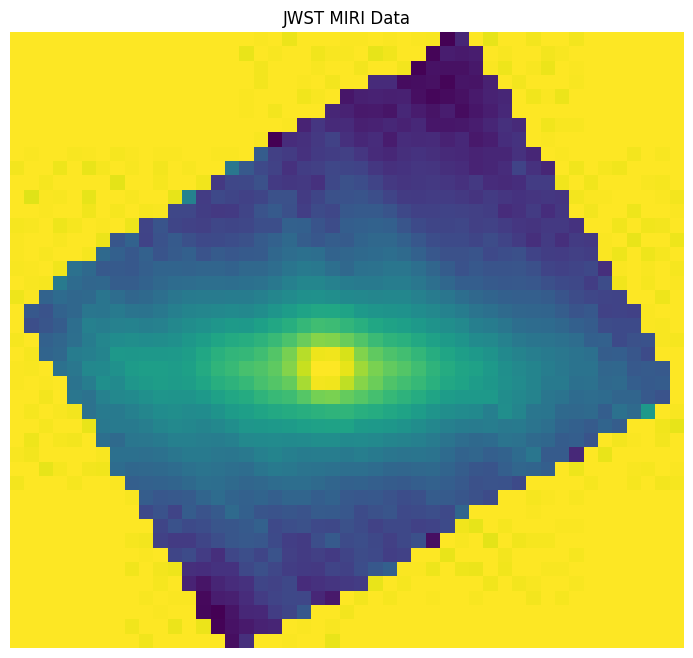

In [ ]:
#!mv 'file?uri=mast:JWST/product/jw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg' jwst_miri_data.jpg
!mv 'file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch2-shortmediumlong_s3d.jpg.2' jwst_miri_data.jpg

from PIL import Image

# Specify the file path
file_path = "jwst_miri_data.jpg"

# Open the image using Pillow
image = Image.open(file_path)

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis('off')  # Turn off axes for a clean display
plt.title("JWST MIRI Data")
plt.show()

*Manually download FITS data*

In [ ]:
# Load first file with name: 'mast:JWST/product/jw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits'
!wget "https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/jw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits"

--2024-12-07 15:47:31--  https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/jw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits
Resolving mast.stsci.edu (mast.stsci.edu)... 130.167.220.32, 130.167.220.33
Connecting to mast.stsci.edu (mast.stsci.edu)|130.167.220.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 132068160 (126M) [application/octet-stream]
Saving to: ‘file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits’

file?uri=mast:JWST% 100%[===================>] 125.95M  81.0MB/s    in 1.6s    

2024-12-07 15:47:33 (81.0 MB/s) - ‘file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits’ saved [132068160/132068160]



In [ ]:
# Rename file
!mv 'file?uri=mast:JWST%2Fproduct%2Fjw02016-c1012_t023_miri_ch1-shortmediumlong_s3d.fits' jwst_miri_data.fits

In [ ]:
# Open file
file_path = "jwst_miri_data.fits"

# Open the FITS file
with fits.open(file_path) as hdul:
    # Display the FITS file structure
    hdul.info()

    # Access primary HDU header and data
    primary_header = hdul[0].header
    primary_data = hdul[0].data

# Print header details
print("Primary Header:", repr(primary_header))

# Check the data dimensions and type
if primary_data is not None:
    print("Data shape:", primary_data.shape)
    print("Data type:", primary_data.dtype)
else:
    print("No primary data available.")

Filename: jwst_miri_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     376   ()      
  1  SCI           1 ImageHDU        89   (51, 47, 3438)   float32   
  2  ERR           1 ImageHDU        12   (51, 47, 3438)   float32   
  3  DQ            1 ImageHDU        12   (51, 47, 3438)   int32 (rescales to uint32)   
  4  WMAP          1 ImageHDU        10   (51, 47, 3438)   float32   
  5  HDRTAB        1 BinTableHDU    842   12R x 416C   [23A, 5A, 3A, 46A, 7A, 13A, 6A, 5A, 6A, 7A, 13A, 4A, L, D, D, D, D, 32A, 50A, 60A, 13A, 2A, D, 32A, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 35A, D, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 13A, 5A, 5A, D, D, D, D, D, D, D, D, D, 7A, 4A, 11A, D, 2A, D, D, D, D, 6A, D, D, D, 4A, D, D, D, D, D, 3A, 4A, D, D, D, D, D, D, D, D, D, K, 5A, 7A, D, D, D, D, D, D, D, D, D, 6A, D, D, K, K, D, D, K, K, D, D, K, K, K, K, K, D, D, D, D, D, D, D, D, D, K, K, L, L, K, K, D, D, D, D, D, D, D, 